# Participant Feedback Analysis

This notebook summarizes participants' subjective experience with the assistant, including ratings, self-reported usage purposes, and changes in attitudes after the activity. Survey responses are mapped into numeric Likert scores or English multi-select labels, then summarized and plotted.

The outputs distinguish immediate task support, perceived learning value, and perceived risks such as inaccuracy or overreliance.


## Setup

This block imports survey loaders, response mappers, confidence-interval utilities, and plotting helpers. The notebook shows the response mapping and summary tables, while helper functions handle repeated plotting details.


In [1]:
from pathlib import Path
import sys
import warnings
import matplotlib.pyplot as plt

# Suppress display-only warnings so notebook output stays focused on the analysis results.
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="This figure includes Axes that are not compatible with tight_layout")
# Clear figures left open by previous interactive runs before saving new PDFs.
plt.close("all")


def _find_repo_root():
    """Find the repository root from either Jupyter or the test runner."""
    # The working directory may be the repository root or a nested directory.
    # Walking upward makes path resolution stable across both cases.
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "analyze").exists():
            return candidate
    raise RuntimeError("Could not locate repository root.")


def _data_path(*candidates):
    """Return the first existing path across current and legacy data layouts."""
    # Some source files have old EduAnalyze paths; fallbacks keep the notebook portable.
    for candidate in candidates:
        path = Path(candidate)
        if not path.is_absolute():
            path = REPO_ROOT / path
        if path.exists():
            return path
    return REPO_ROOT / candidates[0]


REPO_ROOT = _find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Figures are written here unless the automated test runner redirects them.
FIGURES_DIR = REPO_ROOT / "figures"
SHOW_FIGURES = True
print("Repository:", ".")
print("Figures:", "figures")


Repository: .
Figures: figures


In [2]:
import pandas as pd

import analyze.survey.feedback as survey_feedback
import analyze.visualization.feedback_plots as feedback_plots

FIGURES_DIR.mkdir(parents=True, exist_ok=True)


## Multidimensional Ratings of AI Assistance

This block summarizes post-task ratings of the assistant across multiple quality dimensions. Raw survey responses are mapped to numeric Likert values and then summarized by course and item.

The item-level means show whether participants distinguish answer accuracy, personalization, learning support, and interaction quality.


In [3]:
# Load post-task survey data for experimental users and normalize responses.
post_df = survey_feedback.load_postsurvey_data()
post_df = survey_feedback.map_likert_scale_values(post_df)
post_df = survey_feedback.map_multiselect_values(post_df)

# These are the rating dimensions included in the feedback figure.
rating_items = [
    "Response Accuracy",
    "Question Comprehension",
    "Response Personalization",
    "Learning Progress Awareness",
    "Course Learning Effectiveness",
    "Assignment Effectiveness",
    "Review Effectiveness",
    "Exam Effectiveness",
    "Politeness",
    "Patience",
    "Enjoyability",
    "Exploration Encouragement",
]
rating_items = [item for item in rating_items if item in post_df.columns]

# Long-form summary makes the item/course means inspectable before plotting.
rating_summary = (
    post_df
    .melt(id_vars=["course"], value_vars=rating_items, var_name="item", value_name="rating")
    .query("rating > 0")
    .groupby(["course", "item"])
    .agg(n=("rating", "count"), mean=("rating", "mean"), sd=("rating", "std"))
    .round(3)
    .reset_index()
)
rating_summary.head(12)


Loading Post-Survey Data
Loaded post-survey for 346 users

Loading valid users...
  Loaded 81 Python users and 237 Math users
    Python - Treatment: 54, Control: 27
    Math - Treatment: 158, Control: 79
Loaded 212 valid experiment users from validuser_merged.csv
Filtered to 212 experiment group users with post-survey data

Mapping Likert scale values...

Mapping multi-select values to English...


,course,item,n,mean,sd
0,math,Assignment Effectiveness,156,4.372,0.813
1,math,Course Learning Effectiveness,155,4.181,0.841
2,math,Enjoyability,156,3.885,0.787
3,math,Exam Effectiveness,152,3.836,1.076
4,math,Exploration Encouragement,156,3.679,0.880
5,math,Learning Progress Awareness,154,2.916,0.921
6,math,Patience,156,4.429,1.023
7,math,Politeness,156,4.571,0.858
8,math,Question Comprehension,155,4.090,0.678
9,math,Response Accuracy,156,3.923,0.714


Saved plot to: feedback-likert-python-math.pdf


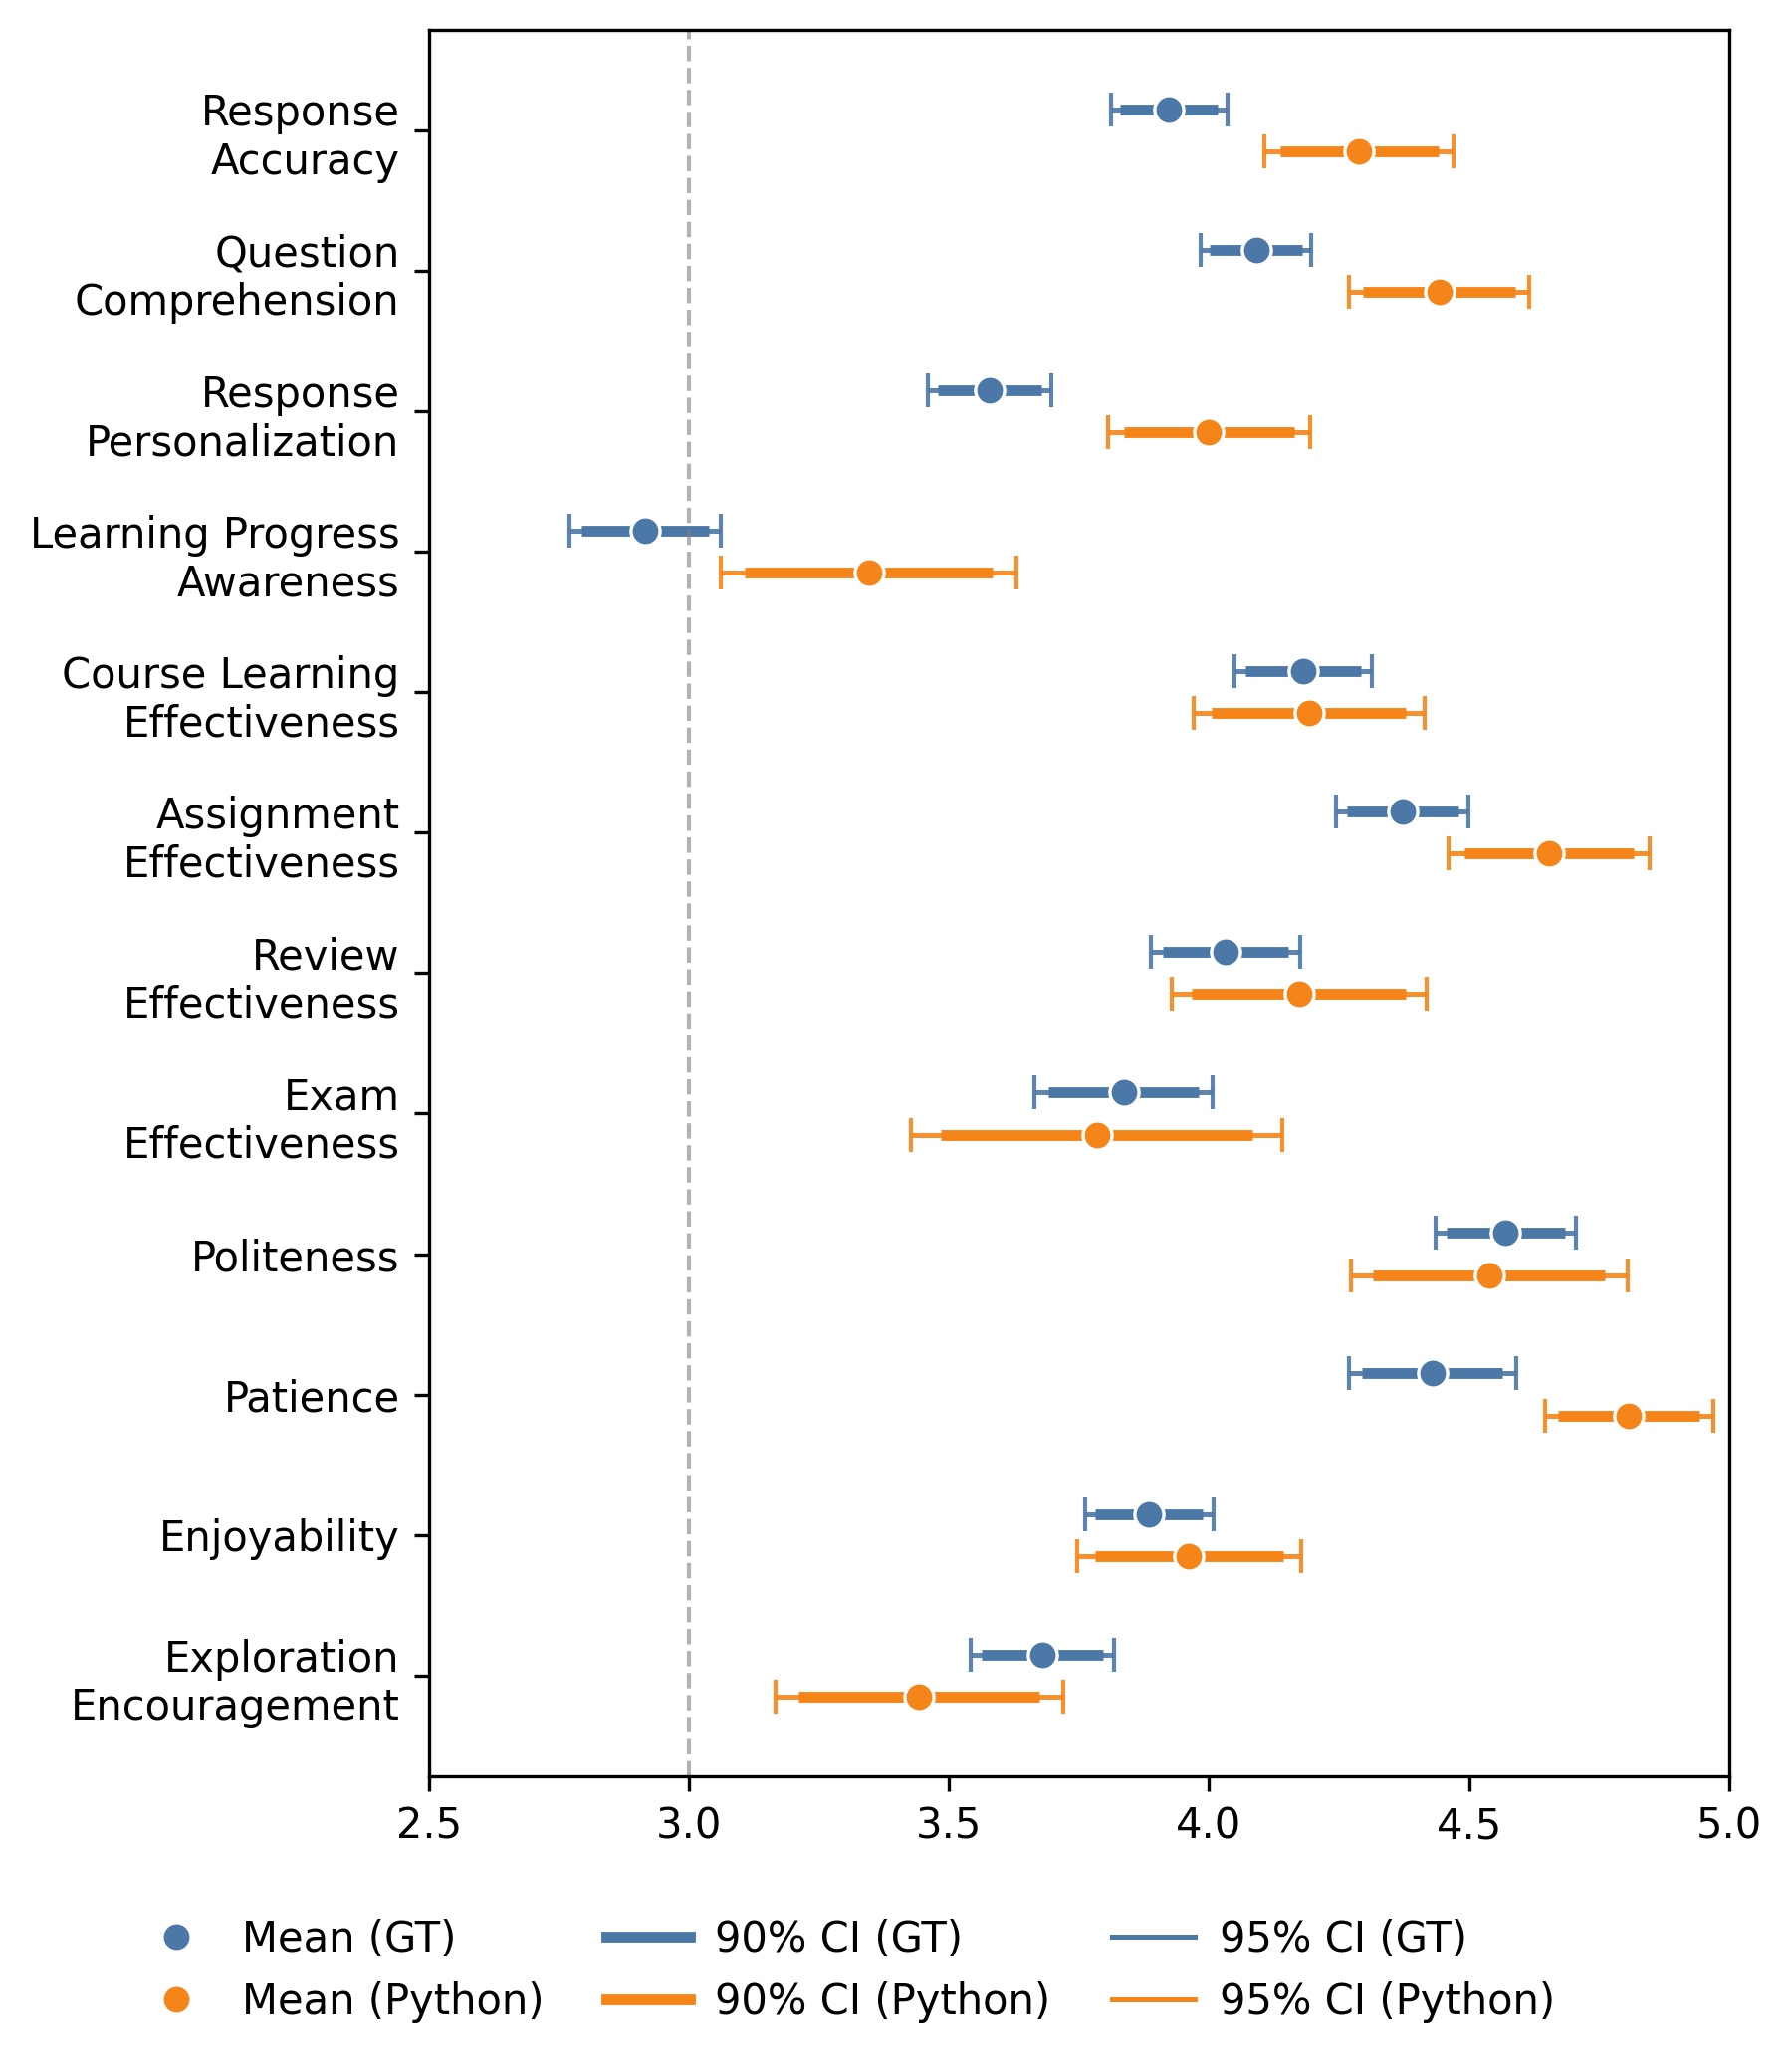

,course,item,n,mean,sd
0,math,Assignment Effectiveness,156,4.372,0.813
1,math,Course Learning Effectiveness,155,4.181,0.841
2,math,Enjoyability,156,3.885,0.787
3,math,Exam Effectiveness,152,3.836,1.076
4,math,Exploration Encouragement,156,3.679,0.880


In [4]:
# The helper draws means with 90% and 95% confidence intervals.
fig, _ax = feedback_plots.plot_likert_point_ci_by_course(
    post_df,
    rating_items,
    title="Post-task AI assistance ratings",
    course_colors={"math": "#4C78A8", "python": "#F58518"},
)
feedback_plots.save_and_maybe_show(fig, FIGURES_DIR / "feedback-likert-python-math.pdf", show=SHOW_FIGURES)
rating_summary.head()


## Self-Reported Usage Objectives and Integration Patterns

This block summarizes how participants say they used the assistant and what they found helpful. Multi-select responses are split into individual labels, counted, and then plotted as donut charts.

The counts show whether students mainly used the assistant for answers, explanations, checking, or broader learning support.



目的_1
               response   n
       Specific answers 155
    Answer explanations 151
   Concept explanations 126
      Solution approach 122
        Answer checking  86
      Summarize sources  58
    Problem suggestions  24
Unable to use assistant   6
      Variant questions   1

Generating pie chart for: 目的_1
Saved plot to: feedback-objectives.pdf


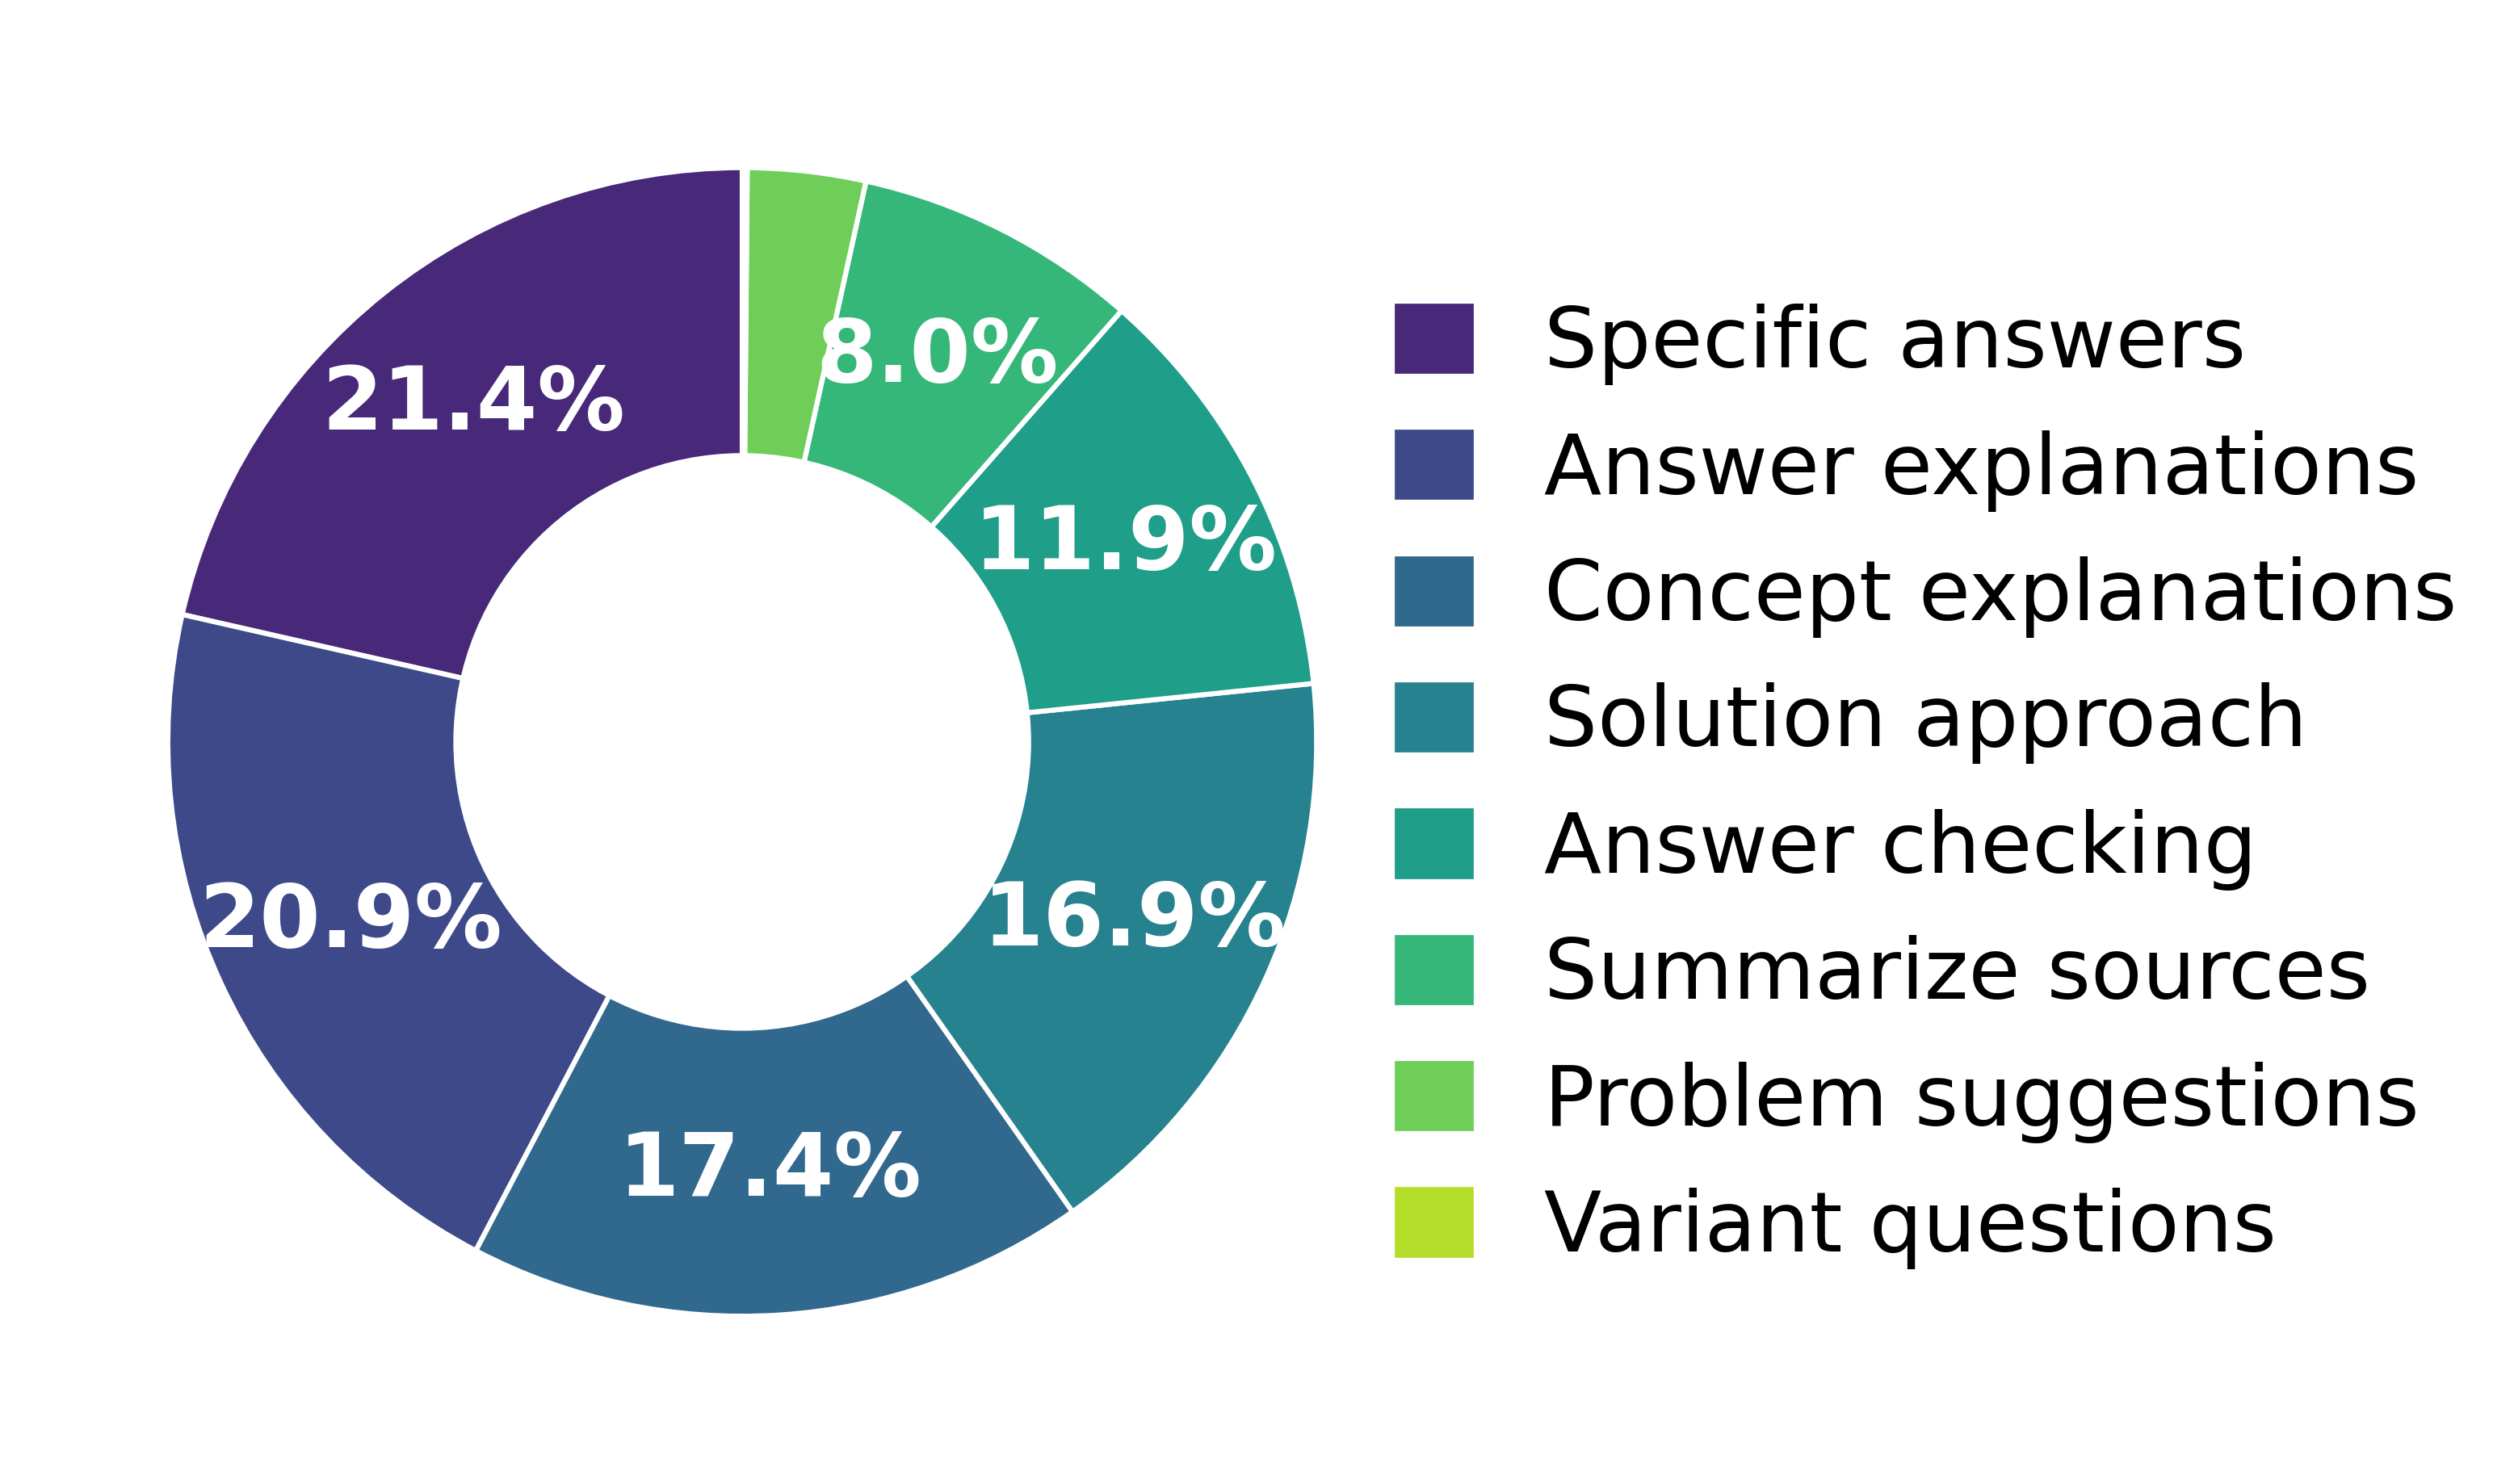


目的_3
               response   n
         Use when stuck 141
       Early-stage only  87
    Throughout learning  76
      Late-stage review  62
             Rarely use  19
Unable to use assistant   6

Generating pie chart for: 目的_3
Saved plot to: feedback-methods.pdf


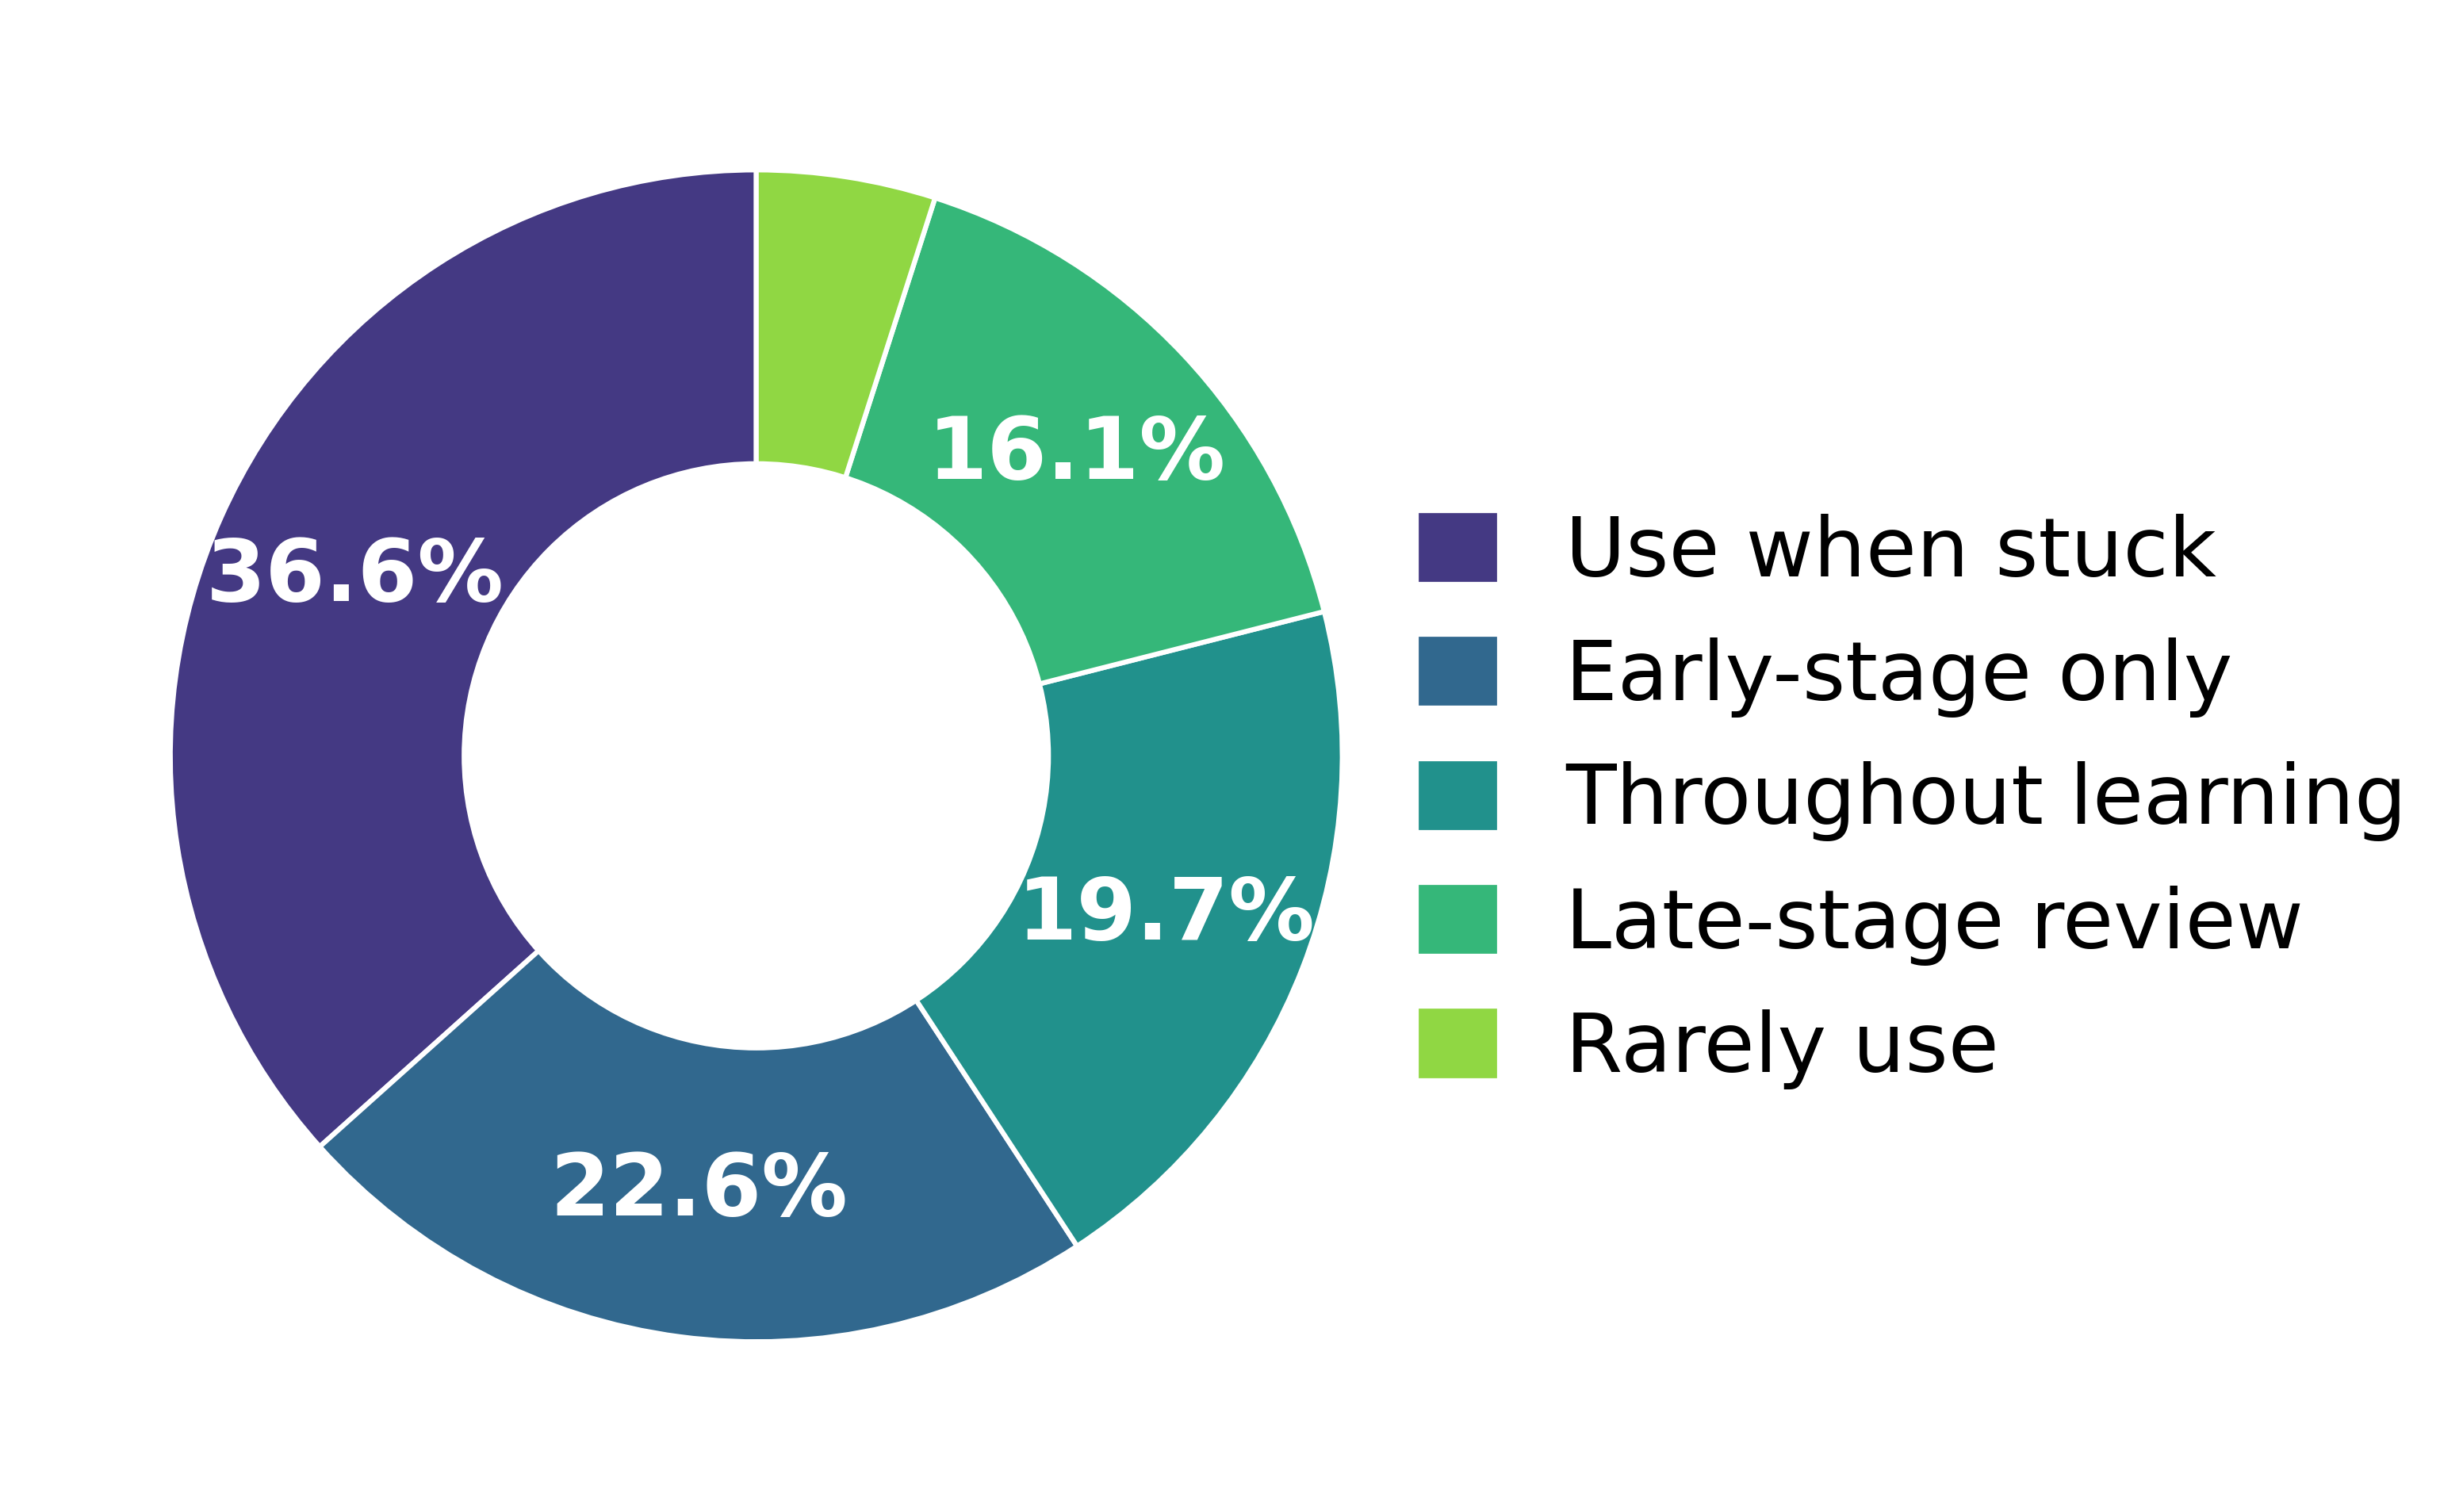


目的_2
               response   n
    Answer explanations 153
   Concept explanations 148
        Problem answers 135
      Solution approach 134
        Answer checking 105
      Summarize sources  86
Unable to use assistant   6
                No help   2

Generating pie chart for: 目的_2
Saved plot to: feedback-effective-aspects.pdf


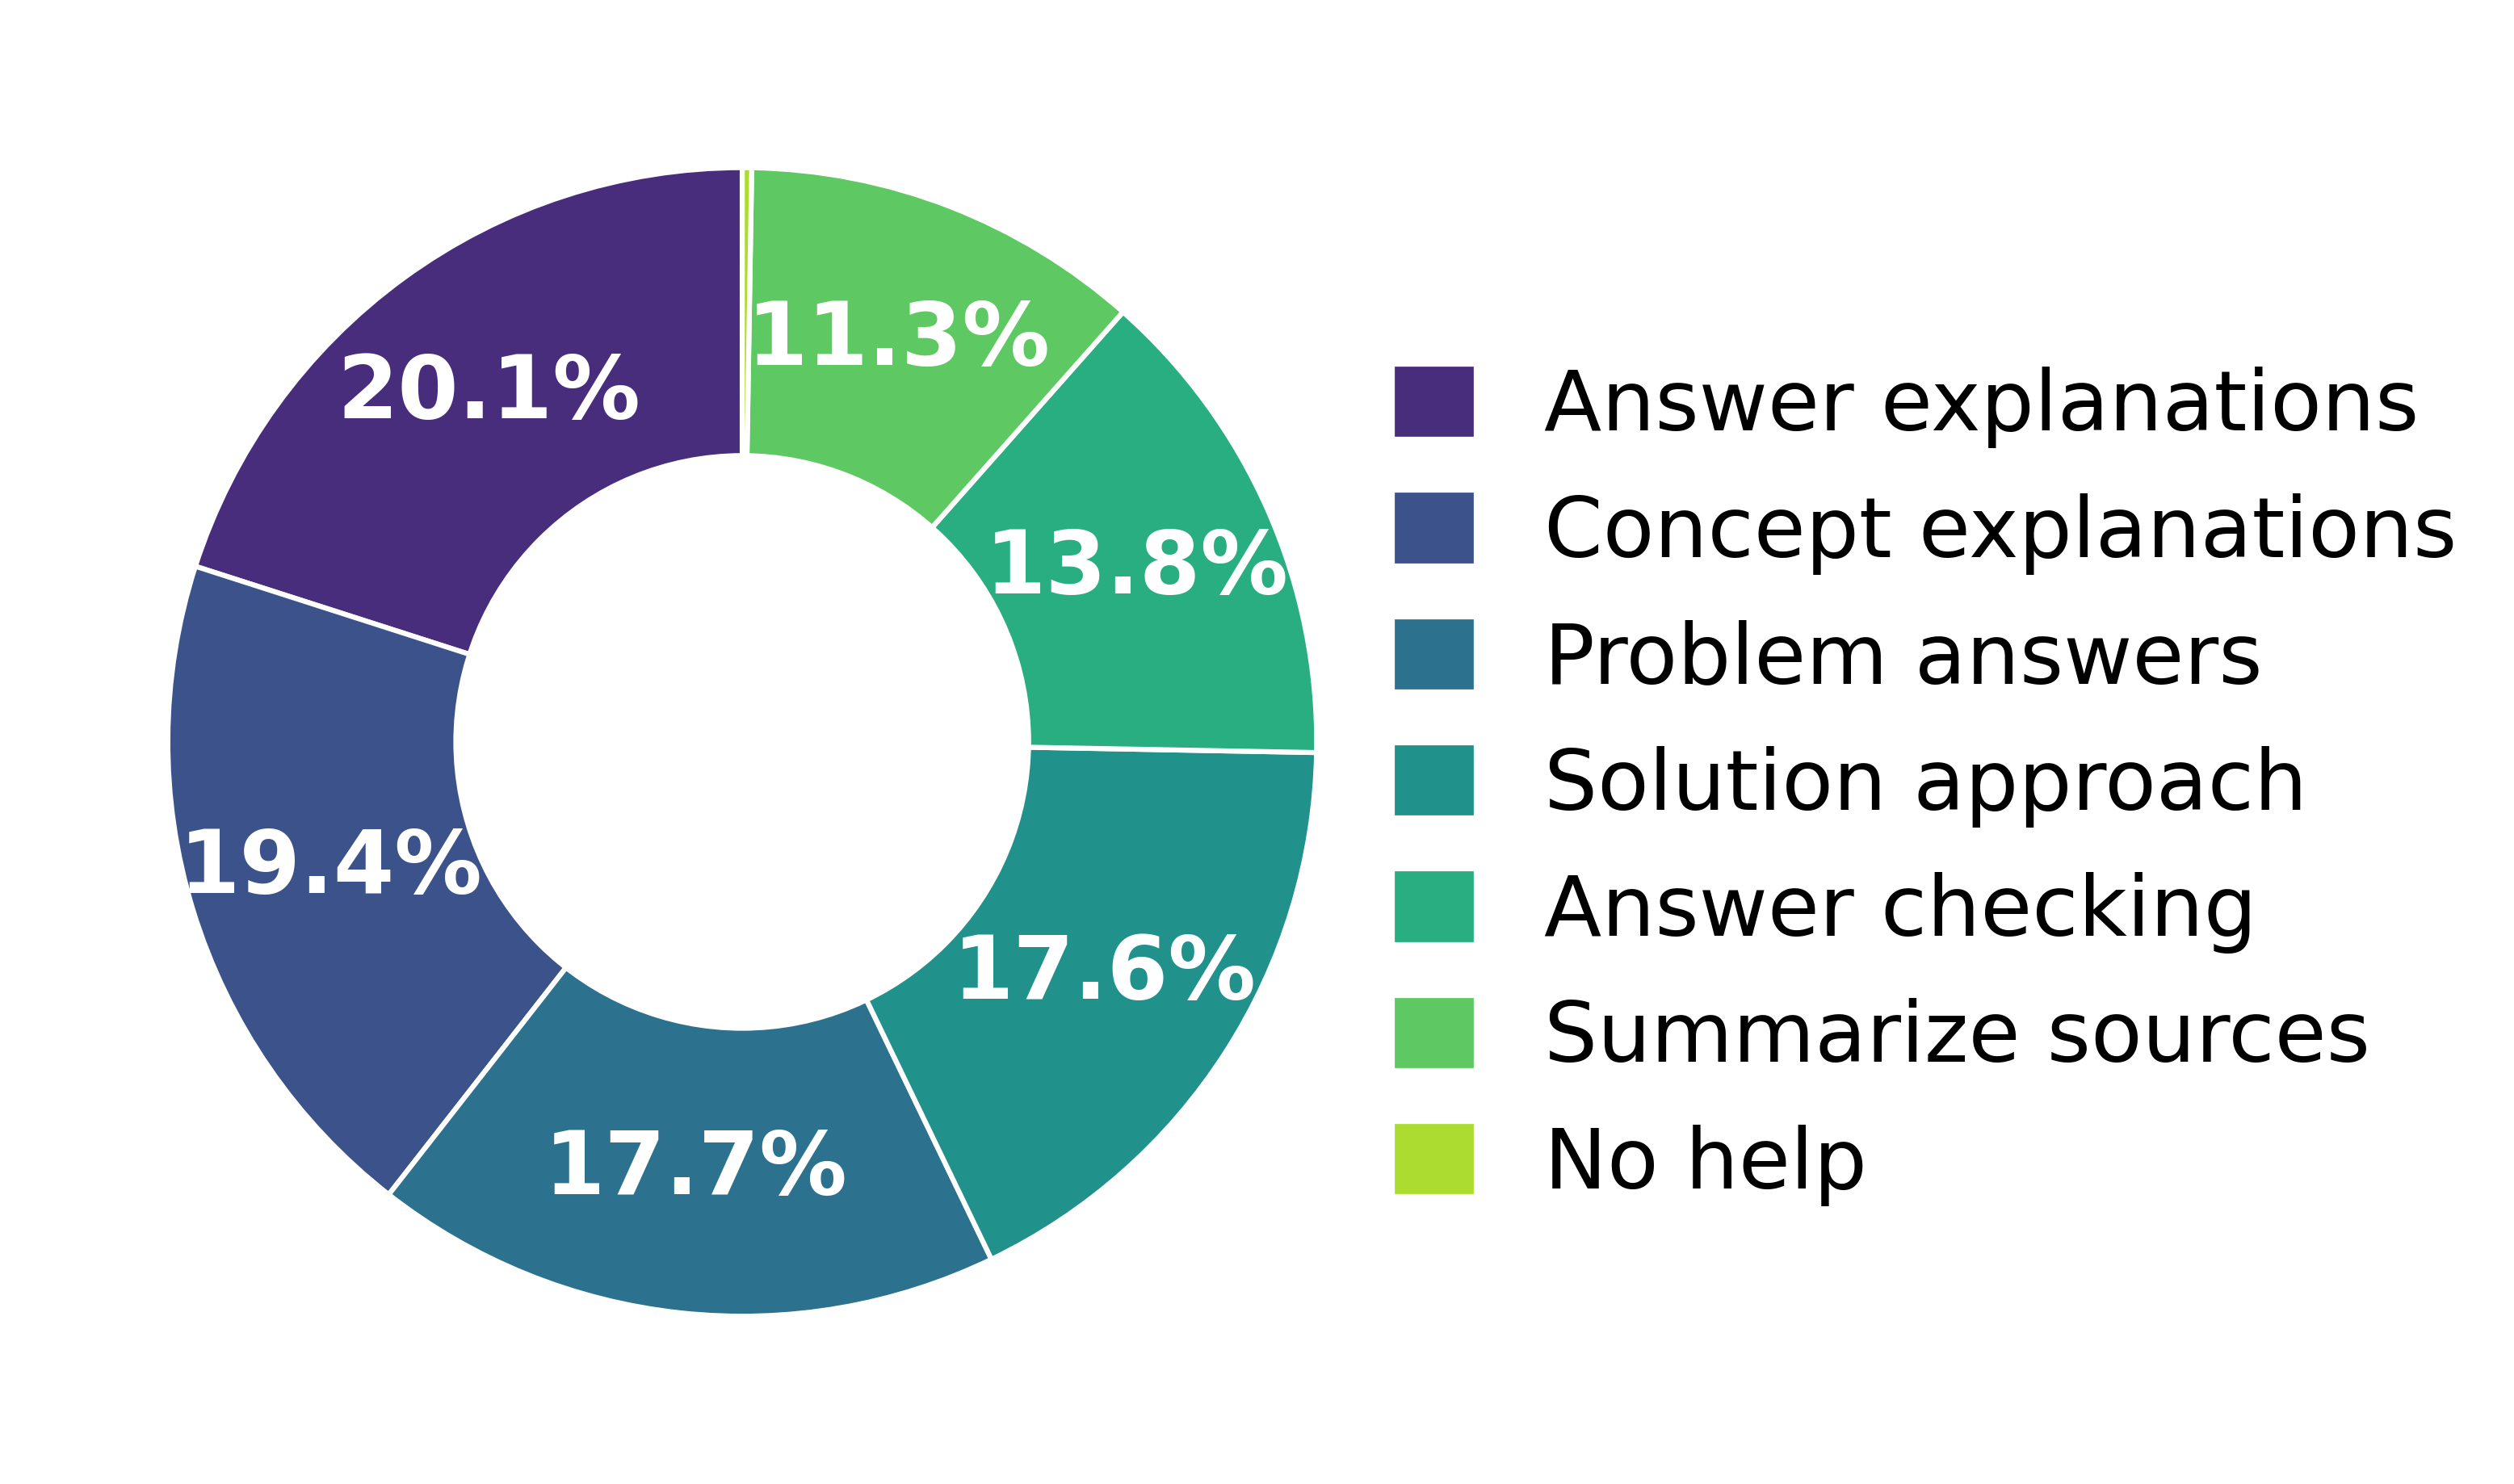

In [5]:
# Each source column is a multi-select survey question.
# We print the counts first so the donut chart is not a black-box transformation.
multiselect_outputs = {
    "目的_1": "feedback-objectives.pdf",
    "目的_3": "feedback-methods.pdf",
    "目的_2": "feedback-effective-aspects.pdf",
}

for column, filename in multiselect_outputs.items():
    counts = post_df[column].explode().value_counts().rename_axis("response").reset_index(name="n")
    print(f"\n{column}")
    print(counts.to_string(index=False))
    fig, _ax = feedback_plots.plot_multi_select_pie(post_df, column)
    feedback_plots.save_and_maybe_show(fig, FIGURES_DIR / filename, show=SHOW_FIGURES)


## Pre/Post Attitude Shifts

This block measures changes in willingness to use AI and perceived risks after the activity. For each participant, it computes post-minus-pre willingness and risk indicators, then compares distributions or mean changes by randomized group and course.

The resulting plots show whether direct exposure changes enthusiasm, concern about inaccuracy, or concern about overreliance.


In [6]:
# Load matched pre/post attitude responses for both experimental and control users.
attitudes_df = survey_feedback.load_prepost_attitudes()

# Willingness is numeric, so the individual-level change is a simple difference.
attitudes_df = attitudes_df.copy()
attitudes_df["willingness_delta"] = attitudes_df["post_willingness"] - attitudes_df["pre_willingness"]
attitude_summary = (
    attitudes_df
    .groupby(["course", "group"])
    .agg(n=("username", "count"), willingness_delta=("willingness_delta", "mean"))
    .round(3)
)
attitude_summary



Loading Pre/Post Attitudes Data

Loading valid users...
  Loaded 81 Python users and 237 Math users
    Python - Treatment: 54, Control: 27
    Math - Treatment: 158, Control: 79
Loaded pre/post attitude data for 318 valid users


n  willingness_delta
course group                        
math   0       79              0.000
       1      158              0.070
python 0       27              0.111
       1       54              0.093

Saved plot to: feedback-willingness-delta-combined.pdf


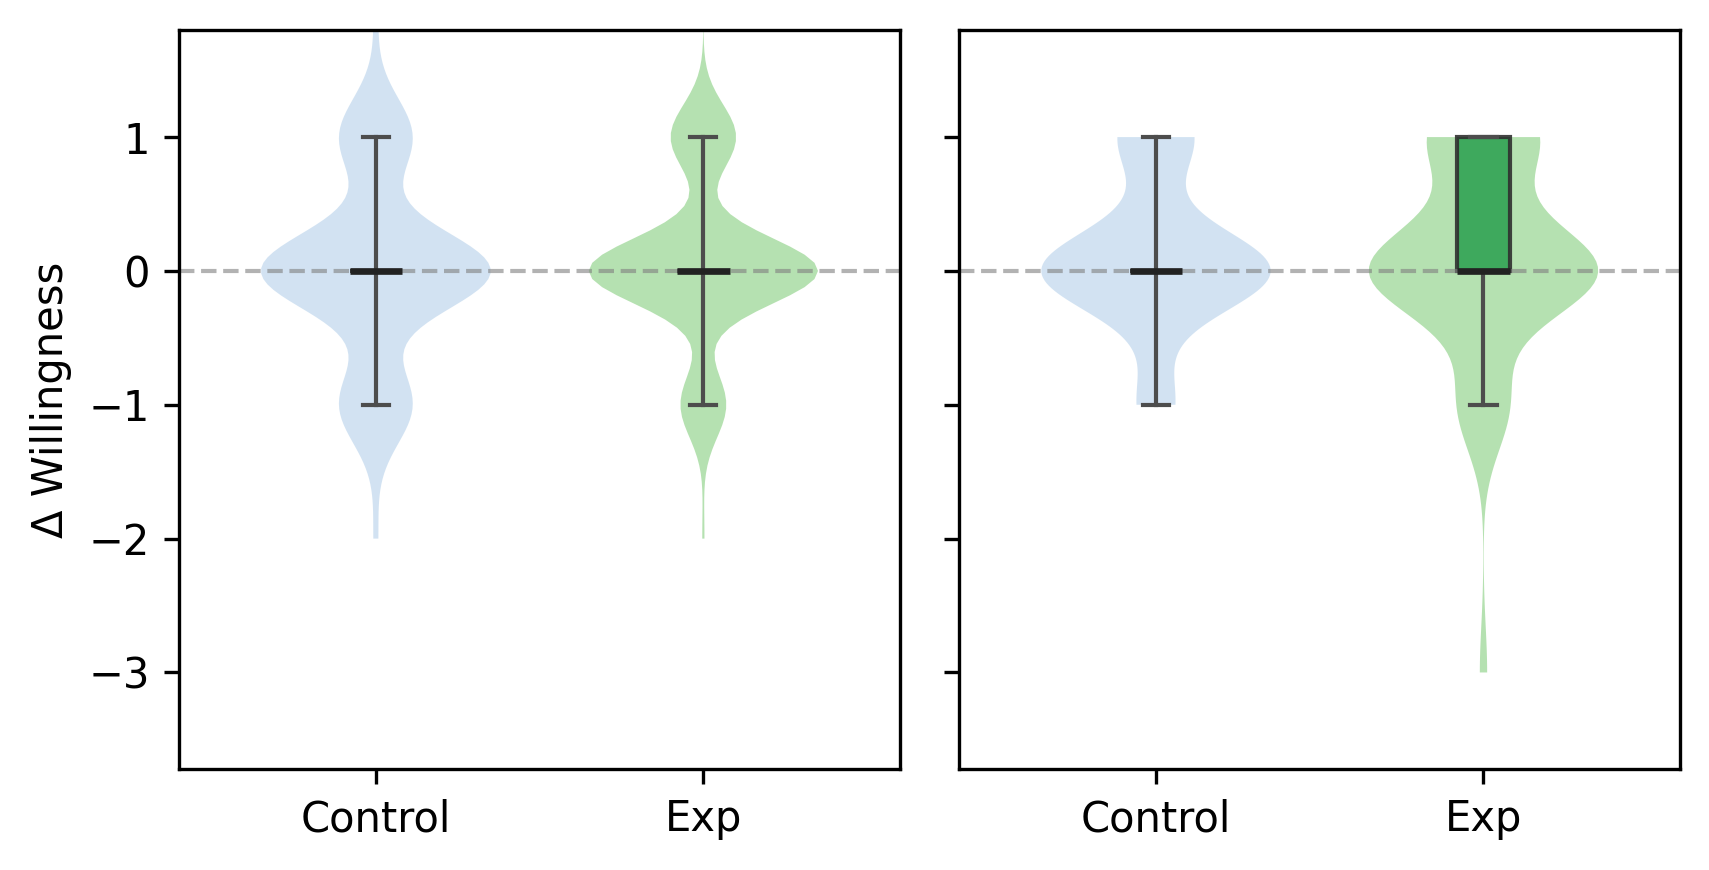

Saved plot to: feedback-risk-delta-combined.pdf


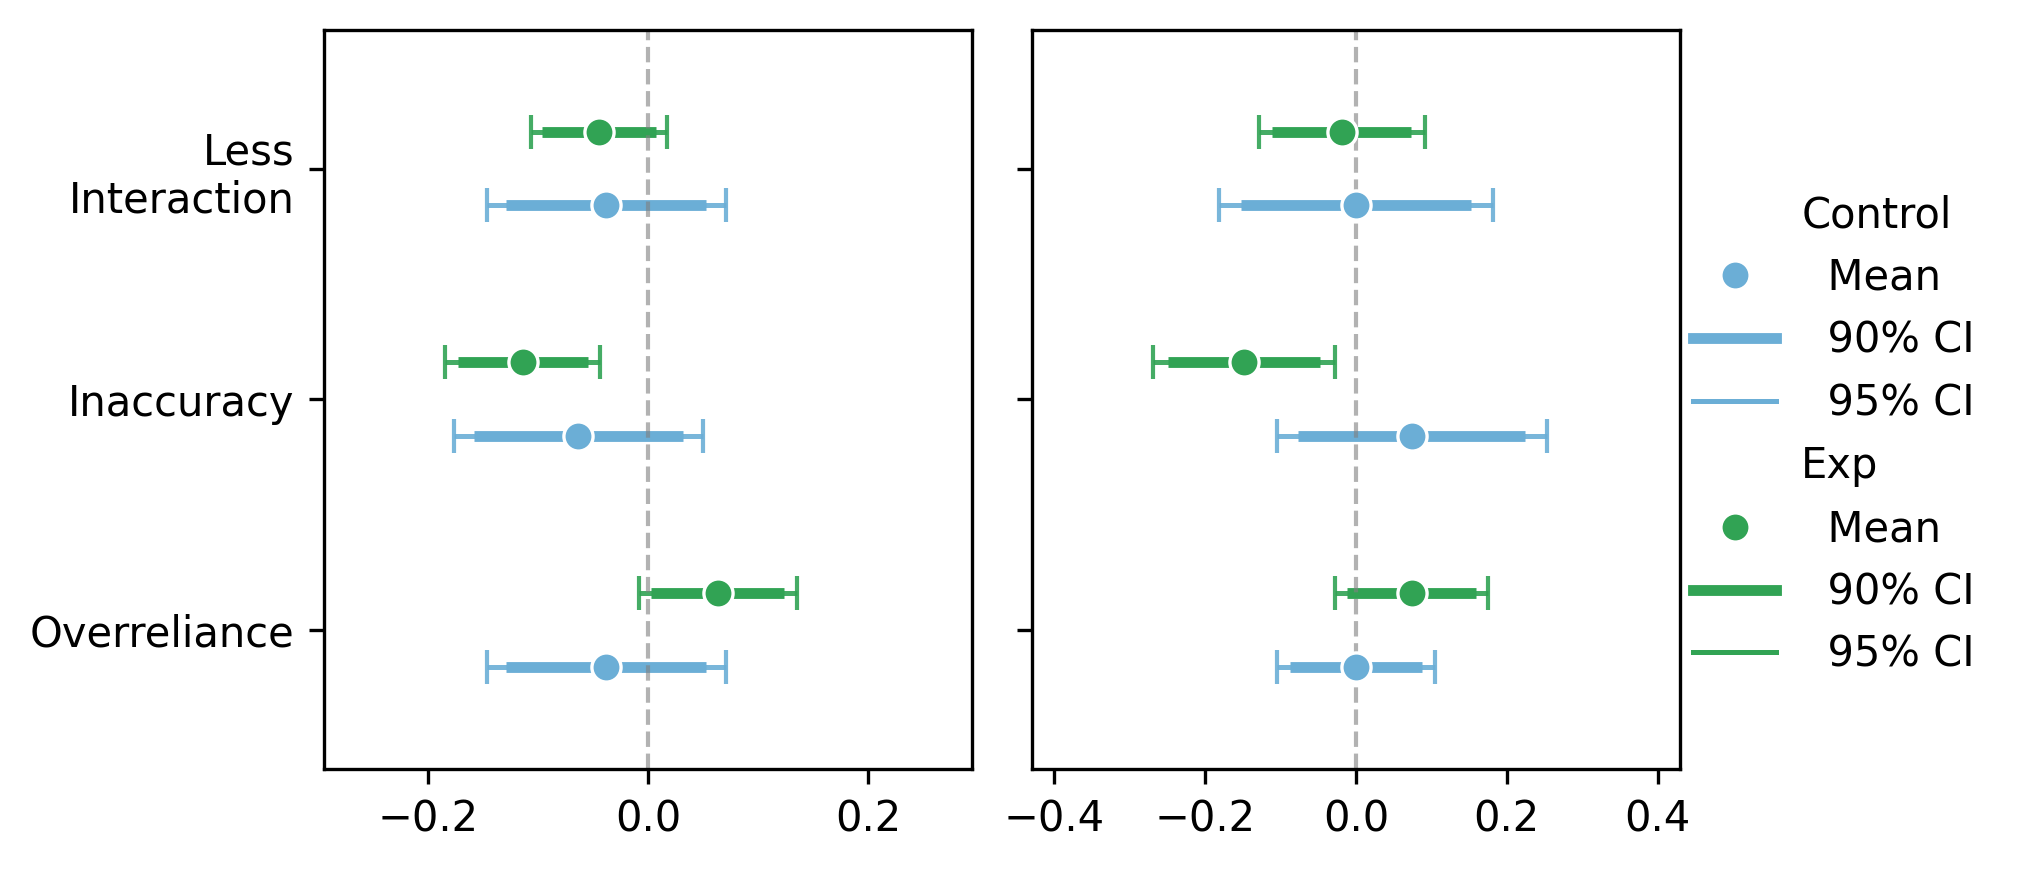

In [7]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Split by course so both attitude figures use the same two-panel layout.
df_math_att = attitudes_df[attitudes_df["course"] == "math"].copy()
df_python_att = attitudes_df[attitudes_df["course"] == "python"].copy()

# Willingness: plot the full distribution of individual post-minus-pre changes.
fig_w, axes_w = plt.subplots(1, 2, figsize=(5.8, 3.0), dpi=300, sharey=True)
if not df_math_att.empty:
    feedback_plots.plot_willingness_delta_violin_box(
        df_math_att,
        title=None,
        control_label="Control",
        exp_label="Exp",
        show_legend=False,
        ax=axes_w[0],
    )
    axes_w[0].set_ylabel("Δ Willingness")
if not df_python_att.empty:
    feedback_plots.plot_willingness_delta_violin_box(
        df_python_att,
        title=None,
        control_label="Control",
        exp_label="Exp",
        show_legend=False,
        ax=axes_w[1],
    )
    axes_w[1].set_ylabel("")
fig_w.tight_layout()
feedback_plots.save_and_maybe_show(fig_w, FIGURES_DIR / "feedback-willingness-delta-combined.pdf", show=SHOW_FIGURES)

# Risk perceptions: plot mean change and confidence intervals for each risk item.
fig_r, axes_r = plt.subplots(1, 2, figsize=(5.8, 3.0), dpi=300, sharey=True)
if not df_math_att.empty:
    feedback_plots.plot_risk_delta_by_group(
        df_math_att,
        risk_items=survey_feedback.RISK_OVERLAP_ITEMS,
        risk_labels=survey_feedback.RISK_LABELS,
        ax=axes_r[0],
        show_legend=False,
    )
if not df_python_att.empty:
    feedback_plots.plot_risk_delta_by_group(
        df_python_att,
        risk_items=survey_feedback.RISK_OVERLAP_ITEMS,
        risk_labels=survey_feedback.RISK_LABELS,
        ax=axes_r[1],
        show_legend=False,
    )

# Add one shared legend so both course panels use the same visual encoding.
control_color = "#6baed6"
exp_color = "#31a354"
legend_handles = [
    Line2D([], [], linestyle="none", label="Control"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor=control_color,
           markeredgecolor="white", markeredgewidth=0.8, markersize=7, label="  Mean"),
    Line2D([0, 1], [0, 0], color=control_color, linewidth=2.6, label="  90% CI"),
    Line2D([0, 1], [0, 0], color=control_color, linewidth=1.2, label="  95% CI"),
    Line2D([], [], linestyle="none", label="Exp"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor=exp_color,
           markeredgecolor="white", markeredgewidth=0.8, markersize=7, label="  Mean"),
    Line2D([0, 1], [0, 0], color=exp_color, linewidth=2.6, label="  90% CI"),
    Line2D([0, 1], [0, 0], color=exp_color, linewidth=1.2, label="  95% CI"),
]
fig_r.legend(
    handles=legend_handles,
    frameon=False,
    loc="center left",
    bbox_to_anchor=(0.96, 0.5),
    ncol=1,
    columnspacing=1.2,
    handletextpad=0.6,
)
fig_r.tight_layout()
feedback_plots.save_and_maybe_show(fig_r, FIGURES_DIR / "feedback-risk-delta-combined.pdf", show=SHOW_FIGURES)


## Outputs

The notebook writes the rating, multi-select, willingness-change, and risk-change feedback figures.
